# PCA ablation results

Load `results.csv` from the PCA component ablation script and compare runs. The baseline (no ablated components) is shown separately from leave-one-out (or other) ablations.

In [1]:
from pathlib import Path

import ast
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_PATH = Path("../results.csv")
df = pd.read_csv(RESULTS_PATH)
df["ablated_list"] = df["ablated_components"].apply(ast.literal_eval)
df["is_baseline"] = df["ablated_list"].apply(len) == 0
baseline = df[df["is_baseline"]].iloc[0]
abl = df[~df["is_baseline"]].copy()
one_pc = abl[abl["ablated_list"].apply(len) == 1].copy()
if len(one_pc) > 0:
    one_pc["pc_idx"] = one_pc["ablated_list"].apply(lambda x: x[0])
    one_pc = one_pc.sort_values("pc_idx")

print(f"Loaded {len(df)} runs from {RESULTS_PATH.resolve()}")
df.head()

Loaded 25 runs from /home/mila/s/sobralm/auditorydecoding/results.csv


,name,ablated_components,n_components,valid_accuracy,valid_balanced_accuracy,valid_f1_macro,delta_valid_f1_macro,ablated_list,is_baseline
0,baseline_all_components,[],24,0.725904,0.693644,0.697949,0.000000,[],True
1,drop_pc_0,[0],24,0.725904,0.690298,0.695440,-0.002509,[0],False
2,drop_pc_1,[1],24,0.707831,0.672599,0.676715,-0.021234,[1],False
3,drop_pc_2,[2],24,0.704819,0.668534,0.672702,-0.025247,[2],False
4,drop_pc_3,[3],24,0.701807,0.667814,0.671396,-0.026554,[3],False


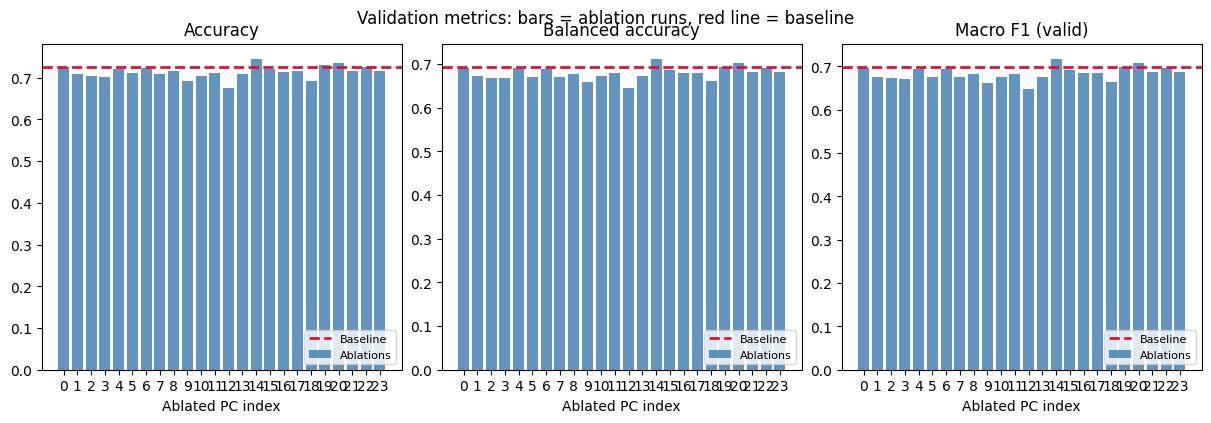

In [2]:
metric_cols = [
    "valid_accuracy",
    "valid_balanced_accuracy",
    "valid_f1_macro",
]
titles = ["Accuracy", "Balanced accuracy", "Macro F1 (valid)"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

for ax, col, title in zip(axes, metric_cols, titles, strict=True):
    y_b = float(baseline[col])
    ax.axhline(y_b, color="crimson", linestyle="--", linewidth=2, label="Baseline")
    if len(one_pc) == len(abl) and len(one_pc) > 0:
        x = one_pc["pc_idx"].to_numpy()
        y = one_pc[col].to_numpy(dtype=float)
        ax.bar(x, y, color="steelblue", alpha=0.85, label="Ablations")
        ax.set_xticks(x)
        ax.set_xlabel("Ablated PC index")
    else:
        order = abl.sort_values(col, ascending=False)
        ax.barh(order["name"], order[col], color="steelblue", alpha=0.85)
        ax.invert_yaxis()
        ax.set_ylabel("Run")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8)

fig.suptitle("Validation metrics: bars = ablation runs, red line = baseline", y=1.02)
plt.show()

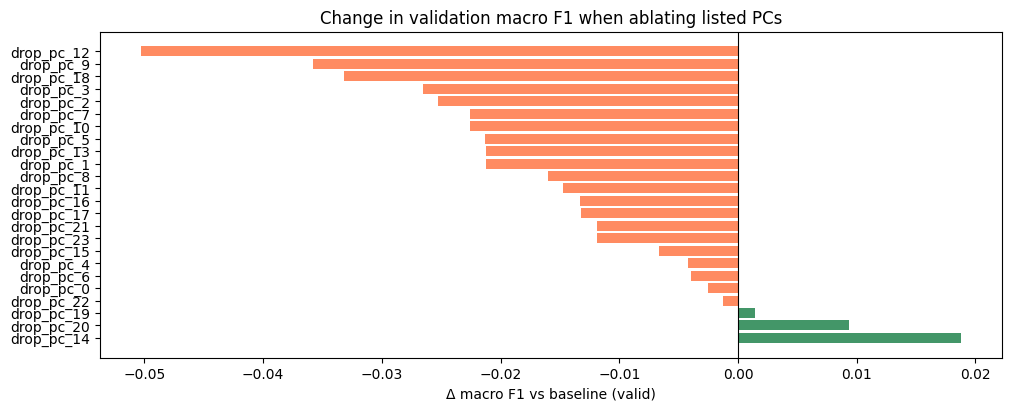

In [3]:
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
order = abl.sort_values("delta_valid_f1_macro")
colors = np.where(order["delta_valid_f1_macro"].to_numpy() >= 0, "seagreen", "coral")
ax.barh(order["name"], order["delta_valid_f1_macro"], color=colors, alpha=0.9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Δ macro F1 vs baseline (valid)")
ax.set_title("Change in validation macro F1 when ablating listed PCs")
ax.invert_yaxis()
plt.show()